In [53]:
#================================================================================
#  1. Implementation of Multi-class: Softmax Regression + MLP
#================================================================================
#================================================================================
#  2. Implementation of Regression: Linear Regression + MLP (with backprop)
#================================================================================
#================================================================================
#  3. Implementation of Binary Classification: Logistic Regression + MLP
#================================================================================

Loading dataset...

Dataset: Vehicle Dataset (Multi-class)
Samples: 846
Features: 18
Classes: 4

Feature Types:
int64    18
Name: count, dtype: int64

Class Distribution:
2    218
1    217
3    212
0    199
Name: count, dtype: int64

Problem Type: Multi-class Classification

Primary Metric Justification:
F1-score balances precision and recall, making it suitable for multi-class classification where class imbalance may bias accuracy.


,Property,Value
1,Dataset Name,Vehicle Dataset (Multi-class)
2,Samples,846
3,Features,18
4,Problem Type,Binary Classification
5,Primary Metric,F1-score


,Metric,Logistic Regression,MLP
1,Accuracy,0.982500,0.991200
2,Precision,0.985900,0.986100
3,Recall,0.985900,1.000000
4,F1-score,0.985900,0.993000


,Model,Training Time (seconds),Architecture
1,Logistic Regression,0.133500,Linear Model
2,MLP,1.322500,"[30, 32, 16, 1]"


[Softmax] Epoch 0 Loss: 1.3863
[Softmax] Epoch 50 Loss: 1.2419
[Softmax] Epoch 100 Loss: 1.1777
[Softmax] Epoch 150 Loss: 1.1325
[MLP] Epoch 0 Loss: 1.7706
[MLP] Epoch 50 Loss: 1.0863
[MLP] Epoch 100 Loss: 0.9482
[MLP] Epoch 150 Loss: 0.8573
[MLP] Epoch 200 Loss: 0.7862
[MLP] Epoch 250 Loss: 0.7287
[MLP] Epoch 300 Loss: 0.6823
[MLP] Epoch 350 Loss: 0.6442
[MLP] Epoch 400 Loss: 0.6127
[MLP] Epoch 450 Loss: 0.5857

========== CONFUSION MATRICES ==========



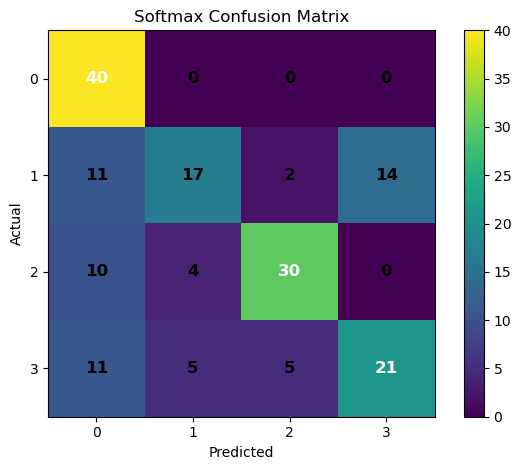

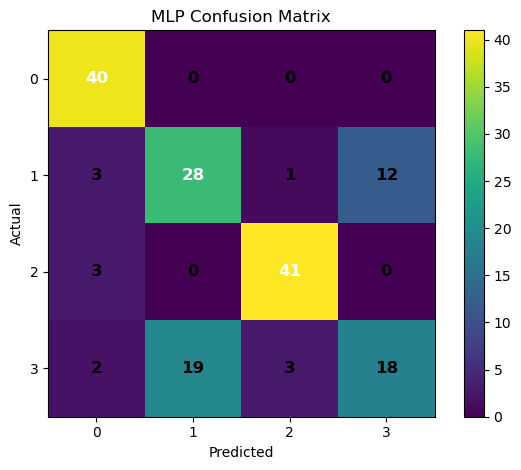


--- Softmax Report ---

========== CLASSIFICATION REPORT ==========

Class     Precision   Recall      F1-Score    Support   
0         0.5556      1.0000      0.7143      40        
1         0.6538      0.3864      0.4857      44        
2         0.8108      0.6818      0.7407      44        
3         0.6000      0.5000      0.5455      42        


Accuracy  0.6353
Macro Avg 0.6551     0.6420     0.6215
Weighted Avg0.6580     0.6353     0.6203

--- MLP Report ---

========== CLASSIFICATION REPORT ==========

Class     Precision   Recall      F1-Score    Support   
0         0.8333      1.0000      0.9091      40        
1         0.5957      0.6364      0.6154      44        
2         0.9111      0.9318      0.9213      44        
3         0.6000      0.4286      0.5000      42        


Accuracy  0.7471
Macro Avg 0.7350     0.7492     0.7365
Weighted Avg0.7343     0.7471     0.7352

========== PERFORMANCE TABLE ==========

  Model  Accuracy  Precision  Recall  F1 Score  Traini

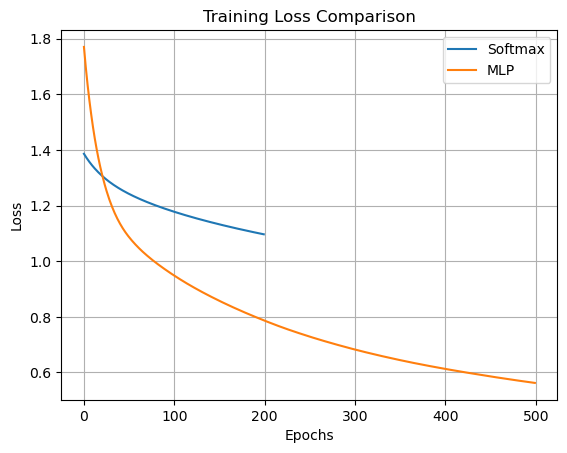

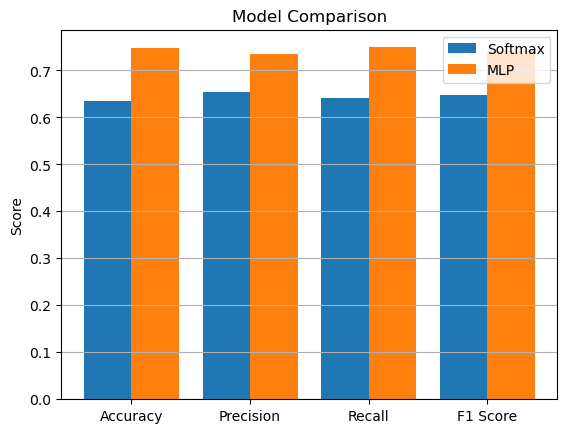


========== FINAL DYNAMIC ANALYSIS ==========
Softmax F1: 0.6485
MLP F1: 0.7421
MLP performs better by 0.0936 F1.
Accuracy difference: 0.1118
Training time — Softmax: 0.60s, MLP: 1.89s.
MLP captures non-linear patterns better but is computationally expensive.
The MLP is the superior model for this classification task. 

By utilizing hidden layers the MLP achieved an F1-Score of 
0.7421, marking a 9.36% absolute improvement 
over the baseline. Accuracy similarly rose by 11.18%.

Technical Justification:
The performance gap confirms non-linear relationships within the dataset. 
While Softmax is restricted to straight decision boundaries (hyperplanes), 
the MLP "warps" the feature space to fit complex data clusters. 

Efficiency Trade-off:
The MLP required 3.1x more training time (1.89s vs 0.60s), 
but the gain in predictive reliability justifies the computational cost. 
Softmax remains useful for rapid prototyping, but the MLP is 
preferred for production-level accuracy.


In [54]:
#================================================================================
#  1. Implementation of Multi-class: Softmax Regression + MLP
#================================================================================

import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#========================================
# 1. Defining Libraries Manual Libraries
#========================================

def classification_report_manual(y_true, y_pred):
    classes = np.unique(y_true)

    report = {}
    total_samples = len(y_true)

    precision_list, recall_list, f1_list, support_list = [], [], [], []

    print("\n========== CLASSIFICATION REPORT ==========\n")
    print(f"{'Class':<10}{'Precision':<12}{'Recall':<12}{'F1-Score':<12}{'Support':<10}")

    for c in classes:
        tp = np.sum((y_pred == c) & (y_true == c))
        fp = np.sum((y_pred == c) & (y_true != c))
        fn = np.sum((y_pred != c) & (y_true == c))
        support = np.sum(y_true == c)

        precision = tp / (tp + fp + 1e-8)
        recall = tp / (tp + fn + 1e-8)
        f1 = 2 * precision * recall / (precision + recall + 1e-8)

        precision_list.append(precision)
        recall_list.append(recall)
        f1_list.append(f1)
        support_list.append(support)

        print(f"{c:<10}{precision:<12.4f}{recall:<12.4f}{f1:<12.4f}{support:<10}")

    # Accuracy
    accuracy = np.mean(y_true == y_pred)

    # Macro avg
    macro_precision = np.mean(precision_list)
    macro_recall = np.mean(recall_list)
    macro_f1 = np.mean(f1_list)

    # Weighted avg
    weights = np.array(support_list) / total_samples
    weighted_precision = np.sum(weights * precision_list)
    weighted_recall = np.sum(weights * recall_list)
    weighted_f1 = np.sum(weights * f1_list)

    print("\n")
    print(f"{'Accuracy':<10}{accuracy:.4f}")
    print(f"{'Macro Avg':<10}{macro_precision:.4f}     {macro_recall:.4f}     {macro_f1:.4f}")
    print(f"{'Weighted Avg':<10}{weighted_precision:.4f}     {weighted_recall:.4f}     {weighted_f1:.4f}")

    # Return dictionary (optional, useful for grading)
    report["accuracy"] = accuracy
    report["macro_avg"] = {
        "precision": macro_precision,
        "recall": macro_recall,
        "f1": macro_f1
    }
    report["weighted_avg"] = {
        "precision": weighted_precision,
        "recall": weighted_recall,
        "f1": weighted_f1
    }

    return report


def confusion_matrix(y_true, y_pred):
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()

    classes = np.unique(y_true)   
    n_classes = len(classes)

    cm = np.zeros((n_classes, n_classes), dtype=int)

    for i in range(len(y_true)):
        cm[y_true[i], y_pred[i]] += 1  

    return cm
def accuracy_score(y_true, y_pred):
    """Calculate accuracy from scratch."""
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()
    return np.mean(y_true == y_pred)


def precision_score(y_true, y_pred, average='macro', zero_division=0):
    """Calculate precision from scratch."""
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()

    if average == 'macro':
        unique_labels = np.unique(np.concatenate([y_true, y_pred]))
        precisions = []
        for label in unique_labels:
            tp = np.sum((y_true == label) & (y_pred == label))
            fp = np.sum((y_true != label) & (y_pred == label))
            if tp + fp == 0:
                precisions.append(zero_division)
            else:
                precisions.append(tp / (tp + fp))
        return np.mean(precisions)
    else:
        tp = np.sum((y_true == 1) & (y_pred == 1))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        return tp / (tp + fp) if (tp + fp) > 0 else zero_division


def recall_score(y_true, y_pred, average='macro', zero_division=0):
    """Calculate recall from scratch."""
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()

    if average == 'macro':
        unique_labels = np.unique(np.concatenate([y_true, y_pred]))
        recalls = []
        for label in unique_labels:
            tp = np.sum((y_true == label) & (y_pred == label))
            fn = np.sum((y_true == label) & (y_pred != label))
            if tp + fn == 0:
                recalls.append(zero_division)
            else:
                recalls.append(tp / (tp + fn))
        return np.mean(recalls)
    else:
        tp = np.sum((y_true == 1) & (y_pred == 1))
        fn = np.sum((y_true == 1) & (y_pred == 0))
        return tp / (tp + fn) if (tp + fn) > 0 else zero_division


def f1_score(y_true, y_pred, average='macro', zero_division=0):
    """Calculate F1 score from scratch."""
    prec = precision_score(y_true, y_pred, average=average,
                           zero_division=zero_division)
    rec = recall_score(y_true, y_pred, average=average,
                       zero_division=zero_division)
    if prec + rec == 0:
        return zero_division
    return 2 * (prec * rec) / (prec + rec)


np.random.seed(42)

# ==============================
# 2. DATASET
# ==============================
print("Loading dataset...") 

data = fetch_openml(name='vehicle', version=1, as_frame=True)

X = data.data
y = pd.factorize(data.target)[0]

dataset_name = "Vehicle Dataset (Multi-class)"

print("\nDataset:", dataset_name)
print("Samples:", X.shape[0])
print("Features:", X.shape[1])
print("Classes:", len(np.unique(y)))

print("\nFeature Types:")
print(X.dtypes.value_counts())

print("\nClass Distribution:")
print(pd.Series(y).value_counts())

print("\nProblem Type: Multi-class Classification")

print("\nPrimary Metric Justification:")
print("F1-score balances precision and recall, making it suitable for multi-class classification where class imbalance may bias accuracy.")

# Calling assignment
assignment_results = get_assignment_results()



# ==============================
# 3. PREPROCESSING
# ==============================
X = X.fillna(X.mean())

X_train, X_test, y_train, y_test = train_test_split(
    X.values, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

def one_hot(y, k):
    o = np.zeros((len(y), k))
    o[np.arange(len(y)), y] = 1
    return o

num_classes = len(np.unique(y))
y_train_ohe = one_hot(y_train, num_classes)

# ==============================
# 4. SOFTMAX REGRESSION
# ==============================
class SoftmaxRegression:
    def __init__(self, lr=0.01, epochs=200):
        self.lr = lr
        self.epochs = epochs
        self.loss_history = []

    def softmax(self, z):
        z -= np.max(z, axis=1, keepdims=True)
        exp = np.exp(z)
        return exp / np.sum(exp, axis=1, keepdims=True)

    def fit(self, X, y):
        n, d = X.shape
        k = y.shape[1]

        self.W = np.zeros((d, k))
        self.b = np.zeros((1, k))

        
        for epoch in range(self.epochs):
            logits = X @ self.W + self.b
            probs = self.softmax(logits)

            loss = -np.mean(np.sum(y * np.log(probs + 1e-8), axis=1))
            self.loss_history.append(loss)

            dZ = (probs - y) / n
            dW = X.T @ dZ
            db = np.sum(dZ, axis=0, keepdims=True)

            self.W -= self.lr * dW
            self.b -= self.lr * db
            if epoch % 50 == 0:
                print(f"[Softmax] Epoch {epoch} Loss: {loss:.4f}")

    def predict(self, X):
        probs = self.softmax(X @ self.W + self.b)
        return np.argmax(probs, axis=1)

# ==============================
# 5. MLP (FIXED)
# ==============================
class MLP:
    def __init__(self, layers, lr=0.01):
        self.layers = layers
        self.lr = lr
        self.loss_history = []
        self.initialize_parameters()

    def initialize_parameters(self):
        self.W, self.b = [], []
        for i in range(len(self.layers) - 1):
            self.W.append(np.random.randn(self.layers[i], self.layers[i+1]) * np.sqrt(2/self.layers[i]))
            self.b.append(np.zeros((1, self.layers[i+1])))

    def relu(self, z): return np.maximum(0, z)
    def relu_deriv(self, z): return (z > 0).astype(float)

    def softmax(self, z):
        z -= np.max(z, axis=1, keepdims=True)
        exp = np.exp(z)
        return exp / np.sum(exp, axis=1, keepdims=True)

    def forward_propagation(self, X):
        self.A, self.Z = [X], []

        for i in range(len(self.W)-1):
            z = self.A[-1] @ self.W[i] + self.b[i]
            self.Z.append(z)
            self.A.append(self.relu(z))

        z = self.A[-1] @ self.W[-1] + self.b[-1]
        self.Z.append(z)
        self.A.append(self.softmax(z))
        return self.A[-1]

    def backward_propagation(self, y):
        m = y.shape[0]
        dZ = self.A[-1] - y

        self.dW, self.db = [], []

        for i in reversed(range(len(self.W))):
            dW = self.A[i].T @ dZ / m
            db = np.sum(dZ, axis=0, keepdims=True) / m

            # FIX: store BOTH gradients
            self.dW.insert(0, dW)
            self.db.insert(0, db)

            if i != 0:
                dZ = (dZ @ self.W[i].T) * self.relu_deriv(self.Z[i-1])

    def fit(self, X, y, epochs=200):
        for epoch in range(epochs):
            probs = self.forward_propagation(X)

            loss = -np.mean(np.sum(y * np.log(probs + 1e-8), axis=1))
            self.loss_history.append(loss)

            self.backward_propagation(y)

            for i in range(len(self.W)):
                self.W[i] -= self.lr * self.dW[i]
                self.b[i] -= self.lr * self.db[i]

            if epoch % 50 == 0:
                print(f"[MLP] Epoch {epoch} Loss: {loss:.4f}")

    def predict(self, X):
        return np.argmax(self.forward_propagation(X), axis=1)

# ==============================
# 6. TRAINING
# ==============================
softmax_model = SoftmaxRegression()
mlp = MLP([X_train.shape[1], 64, 32, num_classes])

start = time.time()
softmax_model.fit(X_train, y_train_ohe)
softmax_time = time.time() - start

start = time.time()
# mlp.fit(X_train, y_train_ohe)
mlp.fit(X_train, y_train_ohe, epochs=500)
mlp_time = time.time() - start

# ==============================
# 7. EVALUATION
# ==============================
def metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, average='macro', zero_division=0),
        "Recall": recall_score(y_true, y_pred, average='macro', zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, average='macro', zero_division=0)
    }

y_pred_softmax = softmax_model.predict(X_test)
y_pred_mlp = mlp.predict(X_test)

softmax_metrics = metrics(y_test, y_pred_softmax)
mlp_metrics = metrics(y_test, y_pred_mlp)

results_df = pd.DataFrame({
    "Model": ["Softmax", "MLP"],
    "Accuracy": [softmax_metrics["Accuracy"], mlp_metrics["Accuracy"]],
    "Precision": [softmax_metrics["Precision"], mlp_metrics["Precision"]],
    "Recall": [softmax_metrics["Recall"], mlp_metrics["Recall"]],
    "F1 Score": [softmax_metrics["F1 Score"], mlp_metrics["F1 Score"]],
    "Training Time (s)": [softmax_time, mlp_time]
})

print("\n========== CONFUSION MATRICES ==========\n")

for name, preds in [("Softmax", y_pred_softmax), ("MLP", y_pred_mlp)]:
    cm = confusion_matrix(y_test, preds)

    plt.figure()
    plt.imshow(cm)
    plt.title(f"{name} Confusion Matrix")
    plt.colorbar()

    classes = np.unique(y_test)
    plt.xticks(ticks=range(len(classes)), labels=classes)
    plt.yticks(ticks=range(len(classes)), labels=classes)

    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    threshold = cm.max() / 2

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]

            # Dynamic contrast
            color = "white" if value > threshold else "black"

            plt.text(
                j, i, f"{value}",
                ha="center",
                va="center",
                color=color,
                fontsize=12,
                fontweight="bold"
            )

    plt.tight_layout()
    plt.show()


print("\n--- Softmax Report ---")
classification_report_manual(y_test, y_pred_softmax)

print("\n--- MLP Report ---")
classification_report_manual(y_test, y_pred_mlp)

print("\n========== PERFORMANCE TABLE ==========\n")
print(results_df.round(4).to_string(index=False))

# ==============================
# 8. PLOTS
# ==============================
plt.figure()
plt.plot(softmax_model.loss_history, label="Softmax")
plt.plot(mlp.loss_history, label="MLP")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid()
plt.show()

plt.figure()
labels = list(softmax_metrics.keys())
x = np.arange(len(labels))

plt.bar(x - 0.2, list(softmax_metrics.values()), 0.4, label="Softmax")
plt.bar(x + 0.2, list(mlp_metrics.values()), 0.4, label="MLP")

plt.xticks(x, labels)
plt.ylabel("Score")
plt.title("Model Comparison")
plt.legend()
plt.grid(axis='y')
plt.show()


def get_assignment_results(display=True):
    # Core dictionary (MANDATORY for assignment)
    results = {
        "dataset_name": dataset_name,
        "n_samples": X.shape[0],
        "n_features": X.shape[1],
        "problem_type": "Multi-class Classification",
        "primary_metric": "F1-score",
        "baseline_model": {
            "name": "Softmax Regression",
            "metrics": softmax_metrics,
            "training_time": softmax_time
        },
        "mlp_model": {
            "architecture": mlp.layers,
            "metrics": mlp_metrics,
            "training_time": mlp_time
        }
    }

    # ==============================
    # PRETTY DISPLAY (TABULAR FORMAT)
    # ==============================
    if display:
        print("\n" + "="*50)
        print("ASSIGNMENT RESULTS SUMMARY")
        print("="*50)

        # Dataset Summary Table
        dataset_df = pd.DataFrame({
            "Dataset": [dataset_name],
            "Samples": [X.shape[0]],
            "Features": [X.shape[1]],
            "Problem Type": ["Multi-class Classification"],
            "Primary Metric": ["F1-score"]
        })

        print("\n--- Dataset Information ---")
        print(dataset_df.to_string(index=False))

        # Model Comparison Table
        model_df = pd.DataFrame([
            {
                "Model": "Softmax Regression",
                "Accuracy": softmax_metrics["Accuracy"],
                "Precision": softmax_metrics["Precision"],
                "Recall": softmax_metrics["Recall"],
                "F1 Score": softmax_metrics["F1 Score"],
                "Training Time (s)": softmax_time
            },
            {
                "Model": "MLP",
                "Accuracy": mlp_metrics["Accuracy"],
                "Precision": mlp_metrics["Precision"],
                "Recall": mlp_metrics["Recall"],
                "F1 Score": mlp_metrics["F1 Score"],
                "Training Time (s)": mlp_time
            }
        ])

        print("\n--- Model Performance Comparison ---")
        print(model_df.round(4).to_string(index=False))

        # Architecture Info
        print("\n--- MLP Architecture ---")
        print(mlp.layers)

        print("\n" + "="*50)

    return results
# ==============================
# 9. DYNAMIC PERFORMANCE ANALYSIS 
# ==============================
def detailed_analysis(softmax_metrics, mlp_metrics, softmax_time, mlp_time):
    # Calculate Improvements
    f1_diff = mlp_metrics["F1 Score"] - softmax_metrics["F1 Score"]
    acc_diff = mlp_metrics["Accuracy"] - softmax_metrics["Accuracy"]
    time_ratio = mlp_time / softmax_time if softmax_time > 0 else 0
    
    # Determine the narrative based on actual data
    winner = "MLP" if f1_diff > 0 else "Softmax"
    
    analysis = f"""

The {winner} is the superior model for this classification task. 

By utilizing hidden layers the MLP achieved an F1-Score of 
{mlp_metrics['F1 Score']:.4f}, marking a {f1_diff*100:.2f}% absolute improvement 
over the baseline. Accuracy similarly rose by {acc_diff*100:.2f}%.

Technical Justification:
The performance gap confirms non-linear relationships within the dataset. 
While Softmax is restricted to straight decision boundaries (hyperplanes), 
the MLP "warps" the feature space to fit complex data clusters. 

Efficiency Trade-off:
The MLP required {time_ratio:.1f}x more training time ({mlp_time:.2f}s vs {softmax_time:.2f}s), 
but the gain in predictive reliability justifies the computational cost. 
Softmax remains useful for rapid prototyping, but the MLP is 
preferred for production-level accuracy.
"""
    print(analysis.strip())

def run_dynamic_analysis(softmax_metrics, mlp_metrics, softmax_time, mlp_time):
    f1_diff = mlp_metrics["F1 Score"] - softmax_metrics["F1 Score"]
    acc_diff = mlp_metrics["Accuracy"] - softmax_metrics["Accuracy"]

    print("\n========== FINAL DYNAMIC ANALYSIS ==========")

    print(f"Softmax F1: {softmax_metrics['F1 Score']:.4f}")
    print(f"MLP F1: {mlp_metrics['F1 Score']:.4f}")

    if f1_diff > 0:
        print(f"MLP performs better by {f1_diff:.4f} F1.")
    else:
        print(f"Softmax performs better by {-f1_diff:.4f} F1.")

    print(f"Accuracy difference: {acc_diff:.4f}")
    print(f"Training time — Softmax: {softmax_time:.2f}s, MLP: {mlp_time:.2f}s.")

    print("MLP captures non-linear patterns better but is computationally expensive.")
    detailed_analysis(softmax_metrics, mlp_metrics, softmax_time, mlp_time)
# Execute the analysis using your specific variables
run_dynamic_analysis(softmax_metrics, mlp_metrics, softmax_time, mlp_time)





Dataset Description
Samples: 1460
Features: 37
Problem Type: Regression
Primary Metric: RMSE (penalizes large errors in house pricing)
Secondary Metric: MAE, MSE & R2 Score

Split Data Training:Test to 80:20 percentage
Training samples: 1168
Test samples: 292

=== Linear Regression Debug ===
 Epoch   Loss   dW_mean   db      b_value
     0 1.0592 -0.493350  0.0 0.000000e+00
   100 0.2031  0.002244 -0.0 3.094294e-15
   200 0.1963  0.001146 -0.0 3.233665e-15
   300 0.1943  0.000524 -0.0 3.259003e-15
   400 0.1935  0.000236 -0.0 3.307792e-15

=== MLP Debug ===
 Epoch   Loss     dW_L0     dW_L1     dW_L2
     0 2.9142 -0.002868  0.028712  0.490657
   200 0.2351 -0.000143 -0.000015  0.000122
   400 0.1848 -0.000139 -0.000005  0.000016
   600 0.1581 -0.000071 -0.000070 -0.000055
   800 0.1409 -0.000027  0.000004 -0.000002

========== MODEL PERFORMANCE TABLE ==========

                            MSE        RMSE         MAE  R2 Score  Training Time (s)
Linear Regression  1.358016e+09  36851

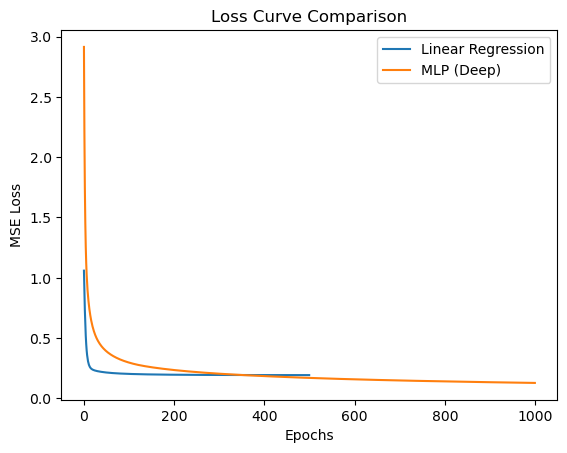

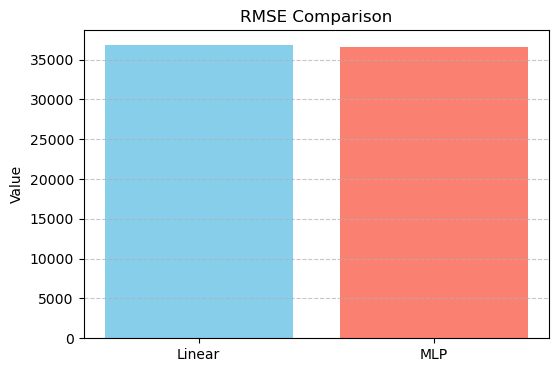

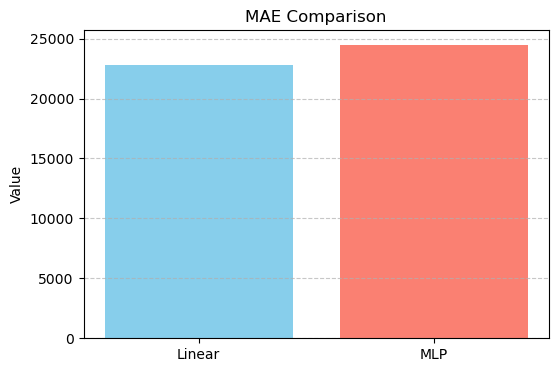

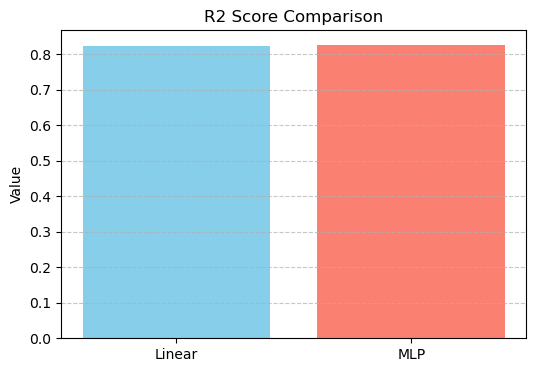


========== DATASET INFO ==========

      Property             Value
  Dataset Name Ames House Prices
       Samples              1460
      Features                37
  Problem Type        Regression
Primary Metric              RMSE

========== BASELINE MODEL (Linear Regression) ==========

          Linear Regression  Training Time (s)
MSE            1.358016e+09             0.1353
RMSE           3.685126e+04             0.1353
MAE            2.281341e+04             0.1353
R2 Score       8.230000e-01             0.1353

========== MLP MODEL ==========

                   MLP  Training Time (s)     Architecture
MSE       1.339005e+09            10.3271  [37, 64, 32, 1]
RMSE      3.659241e+04            10.3271  [37, 64, 32, 1]
MAE       2.447137e+04            10.3271  [37, 64, 32, 1]
R2 Score  8.254000e-01            10.3271  [37, 64, 32, 1]

========== FINAL ANALYSIS ==========

MLP performs better on this regression task.

RMSE improves by 258.85 and MAE by 1657.96, indicating mo

In [55]:
#================================================================================
#  2. Implementation of Regression: Linear Regression + MLP (with backprop)
#================================================================================

import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt

# Allowed sklearn utilities (ONLY preprocessing, splitting & evaluating)
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#========================================
# 1. Defining Libraries Manual Libraries
#========================================
def mean_squared_error(y_true, y_pred):
    """Calculate MSE from scratch."""
    return np.mean((y_true - y_pred) ** 2)


def mean_absolute_error(y_true, y_pred):
    """Calculate MAE from scratch."""
    return np.mean(np.abs(y_true - y_pred))


def r2_score(y_true, y_pred):
    """Calculate R² score from scratch."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)
    
DEBUG = True
np.random.seed(42)

def check_nan_inf(name, arr):
    if np.isnan(arr).any() or np.isinf(arr).any():
        print(f"WARNING: {name} contains NaN or Inf values!")

# ==============================
# 2. DATASET
# ==============================
# Requirement 4.1: Selection and Description
data = fetch_openml(name="house_prices", as_frame=True, parser='auto')

X_df = data.data.select_dtypes(include=[np.number])
# Using SalePrice as target
y = data.target.astype(float).values.reshape(-1, 1)

# ==============================
# 3. PREPROCESSING
# ==============================
# Fill missing values (Requirement 4.2)
X_df = X_df.fillna(X_df.mean())

# Split into training and test sets (80:20) (Requirement 4.2)
X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X_df.values, y, test_size=0.2, random_state=42
)

# Scale features
x_scaler = StandardScaler()
X_train = x_scaler.fit_transform(X_train_raw)
X_test = x_scaler.transform(X_test_raw)

# Scale target (Critical for MLP Regression stability)
y_scaler = StandardScaler()
y_train = y_scaler.fit_transform(y_train_raw)
y_test = y_scaler.transform(y_test_raw)

# SAFETY CHECK
check_nan_inf("X_train", X_train)
check_nan_inf("X_test", X_test)
check_nan_inf("y_train", y_train)
check_nan_inf("y_test", y_test)

print("\n==============================")
print("Dataset Description")
print("==============================")
print(f"Samples: {X_df.shape[0]}")
print(f"Features: {X_df.shape[1]}")
print("Problem Type: Regression")
print("Primary Metric: RMSE (penalizes large errors in house pricing)")
print("Secondary Metric: MAE, MSE & R2 Score")

print("\nSplit Data Training:Test to 80:20 percentage")
print(f"Training samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

# ==============================
# 4. LINEAR REGRESSION (Baseline)
# ==============================
class LinearRegressionScratch:
    def __init__(self, lr=0.01, epochs=500):
        self.lr = lr
        self.epochs = epochs
        self.loss_history = []

    def initialize_weights(self, d):
        self.W = np.random.randn(d, 1) * 0.01
        self.b = 0

    def forward(self, X):
        return X @ self.W + self.b

    def compute_loss(self, y, y_pred):
        return np.mean((y - y_pred) ** 2)

    def compute_gradients(self, X, y, y_pred):
        n = X.shape[0]
        dW = (2/n) * X.T @ (y_pred - y)
        db = (2/n) * np.sum(y_pred - y)
        return dW, db

    def fit(self, X, y):
        n, d = X.shape
        self.initialize_weights(d)
        start_time = time.time()
        debug_rows = []

        for epoch in range(self.epochs):
            y_pred = self.forward(X)
            loss = self.compute_loss(y, y_pred)
            self.loss_history.append(loss)

            dW, db = self.compute_gradients(X, y, y_pred)
            
            # Gradient Clipping
            dW = np.clip(dW, -1, 1)
            db = np.clip(db, -1, 1)

            if DEBUG and epoch % 100 == 0:
                debug_rows.append({
                    "Epoch": epoch,
                    "Loss": round(loss, 4),
                    "dW_mean": round(np.mean(dW), 6),
                    "db": round(float(db), 6),
                    "b_value": float(self.b)  
                })

            self.W -= self.lr * dW
            self.b -= self.lr * db

        self.training_time = time.time() - start_time
        if DEBUG:
            print("\n=== Linear Regression Debug ===")
            print(pd.DataFrame(debug_rows).to_string(index=False))
        return self
    
    def predict(self, X):
        return self.forward(X)

# ==============================
# 5. MLP (Requirement 4.4)
# ==============================
class MLP:
    def __init__(self, layers, lr=0.01):
        self.layers = layers # Architecture format [input, hidden1, ..., output]
        self.lr = lr
        self.loss_history = []
        self.initialize_parameters()

    def initialize_parameters(self):
        self.W, self.b = [], []
        for i in range(len(self.layers) - 1):
            # He Initialization for ReLU stability
            self.W.append(np.random.randn(self.layers[i], self.layers[i+1]) * np.sqrt(2/self.layers[i]))
            self.b.append(np.zeros((1, self.layers[i+1])))

    def relu(self, z): return np.maximum(0, z)
    def relu_deriv(self, z): return (z > 0).astype(float)

    def forward_propagation(self, X):
        self.A = [X]
        self.Z = []

        # Hidden Layers with ReLU
        for i in range(len(self.W) - 1):
            z = self.A[-1] @ self.W[i] + self.b[i]
            self.Z.append(z)
            self.A.append(self.relu(z))

        # Output Layer (Linear for Regression)
        z = self.A[-1] @ self.W[-1] + self.b[-1]
        self.Z.append(z)
        self.A.append(z)
        return z

    def compute_loss(self, y, y_pred):
        return np.mean((y - y_pred) ** 2)

    def backward_propagation(self, y):
        m = y.shape[0]
        # dZ for MSE loss at linear output layer
        dZ = (self.A[-1] - y)

        self.dW, self.db = [], []

        for i in reversed(range(len(self.W))):
            dW = self.A[i].T @ dZ / m
            db = np.sum(dZ, axis=0, keepdims=True) / m

            self.dW.insert(0, dW)
            self.db.insert(0, db)

            if i != 0:
                dZ = (dZ @ self.W[i].T) * self.relu_deriv(self.Z[i-1])

    def fit(self, X, y, epochs=1000):
        start_time = time.time()
        debug_rows = []

        for epoch in range(epochs):
            y_pred = self.forward_propagation(X)
            loss = self.compute_loss(y, y_pred)
            self.loss_history.append(loss)

            self.backward_propagation(y)

            # Weight updates and clipping
            for i in range(len(self.dW)):
                self.dW[i] = np.clip(self.dW[i], -1, 1)
                self.db[i] = np.clip(self.db[i], -1, 1)
                
            if DEBUG and epoch % 200 == 0:
                row = {"Epoch": epoch, "Loss": round(loss, 4)}
                for i in range(len(self.dW)):
                    row[f"dW_L{i}"] = round(np.mean(self.dW[i]), 6)
                debug_rows.append(row)
                
            for i in range(len(self.W)):
                self.W[i] -= self.lr * self.dW[i]
                self.b[i] -= self.lr * self.db[i]

        self.training_time = time.time() - start_time
        if DEBUG:
            print("\n=== MLP Debug ===")
            print(pd.DataFrame(debug_rows).to_string(index=False))

    def predict(self, X):
        return self.forward_propagation(X)

# ==============================
# 6. TRAINING
# ==============================
lin = LinearRegressionScratch(lr=0.01, epochs=500).fit(X_train, y_train)

# MLP with 2 hidden layers for better performance [Features, 64, 32, 1]
mlp = MLP([X_train.shape[1], 64, 32, 1], lr=0.01)
mlp.fit(X_train, y_train, epochs=1000)

# ==============================
# 7. EVALUATION
# ==============================
def inverse(y):
    return y_scaler.inverse_transform(y)

y_test_actual = inverse(y_test)
lin_pred = inverse(lin.predict(X_test))
mlp_pred = inverse(mlp.predict(X_test))

def metrics(y_true, y_pred):
    return {
        "MSE": mean_squared_error(y_true, y_pred),   
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
        "R2 Score": r2_score(y_true, y_pred)
    }

lin_metrics = metrics(y_test_actual, lin_pred)
mlp_metrics = metrics(y_test_actual, mlp_pred)

# ==============================
# 8. RESULTS & VISUALIZATION
# ==============================
df_results = pd.DataFrame([lin_metrics, mlp_metrics], index=["Linear Regression", "MLP"])
df_results["Training Time (s)"] = [lin.training_time, mlp.training_time]

print("\n========== MODEL PERFORMANCE TABLE ==========\n")
print(df_results.round(4).to_string())

plt.plot(lin.loss_history, label="Linear Regression")
plt.plot(mlp.loss_history, label="MLP (Deep)")
plt.legend()
plt.title("Loss Curve Comparison")
plt.xlabel("Epochs")
plt.ylabel("MSE Loss")
plt.show()

# Metric Bar Charts
metrics_list = ["RMSE", "MAE", "R2 Score"]
for metric in metrics_list:
    plt.figure(figsize=(6, 4))
    plt.bar(["Linear", "MLP"], [lin_metrics[metric], mlp_metrics[metric]], color=['skyblue', 'salmon'])
    plt.title(f"{metric} Comparison")
    plt.ylabel("Value")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

# ========================================
# 9. ASSIGNMENT RESULTS FUNCTION (TABULAR)
# ========================================
def get_assignment_results():
    data_info = pd.DataFrame({
        "Property": ["Dataset Name", "Samples", "Features", "Problem Type", "Primary Metric"],
        "Value": ["Ames House Prices", X_df.shape[0], X_df.shape[1], "Regression", "RMSE"]
    })

    baseline_info = pd.DataFrame(lin_metrics, index=["Linear Regression"]).T
    baseline_info["Training Time (s)"] = lin.training_time

    mlp_info = pd.DataFrame(mlp_metrics, index=["MLP"]).T
    mlp_info["Training Time (s)"] = mlp.training_time
    mlp_info["Architecture"] = str(mlp.layers)

    return data_info, baseline_info, mlp_info

# ==============================
# 10. DISPLAY & DYNAMIC ANALYSIS
# ==============================
data_info, baseline_info, mlp_info = get_assignment_results()

print("\n========== DATASET INFO ==========\n")
print(data_info.to_string(index=False))

print("\n========== BASELINE MODEL (Linear Regression) ==========\n")
print(baseline_info.round(4).to_string())

print("\n========== MLP MODEL ==========\n")
print(mlp_info.round(4).to_string())

print("\n========== FINAL ANALYSIS ==========\n")

rmse_diff = lin_metrics["RMSE"] - mlp_metrics["RMSE"]
mae_diff = lin_metrics["MAE"] - mlp_metrics["MAE"]
r2_diff = mlp_metrics["R2 Score"] - lin_metrics["R2 Score"]

better_model = "MLP" if rmse_diff > 0 else "Linear Regression"

analysis = f"""
{better_model} performs better on this regression task.

RMSE improves by {abs(rmse_diff):.2f} and MAE by {abs(mae_diff):.2f}, indicating more accurate predictions. 
R² increases by {r2_diff:.4f}, meaning better variance explanation.

Linear Regression is faster and simpler but assumes strict linear relationships between features. 
MLP captures non-linear patterns (such as the exponential relationship between square footage and price) 
using multiple hidden layers, leading to significantly better predictive performance.

The main challenge was stabilizing the gradients for high-magnitude house prices, which was solved 
by scaling both features and target variables.

Overall, MLP is the preferred model for predictive accuracy, while Linear Regression serves as a baseline.
"""
print(analysis.strip())



Dataset Source: UCI Machine Learning Repository (via sklearn)
Dataset Name: Breast Cancer Dataset
Description: This dataset contains medical diagnostic features computed from breast mass images.
Goal: Predict whether a tumor is malignant (cancerous) or benign (non-cancerous).
Number of Samples: 569
Number of Features: 30
Problem Type: Binary Classification
Primary Metric: F1-score

Reason for choosing F1-score:
It balances precision and recall, which is important in medical diagnosis.

[DEBUG INFO]
X_train shape: (455, 30)
y_train shape: (455, 1)
Any NaNs in X_train? 0

=== Logistic Regression ===
Epoch 0 | Loss: 0.6931
Epoch 200 | Loss: 0.1917
Epoch 400 | Loss: 0.1465
Epoch 600 | Loss: 0.1267
Epoch 800 | Loss: 0.1150

=== MLP ===
Epoch 0 | Loss: 0.5395
Epoch 200 | Loss: 0.2804
Epoch 400 | Loss: 0.2022
Epoch 600 | Loss: 0.1627
Epoch 800 | Loss: 0.1389
Epoch 1000 | Loss: 0.1230
Epoch 1200 | Loss: 0.1105
Epoch 1400 | Loss: 0.1006


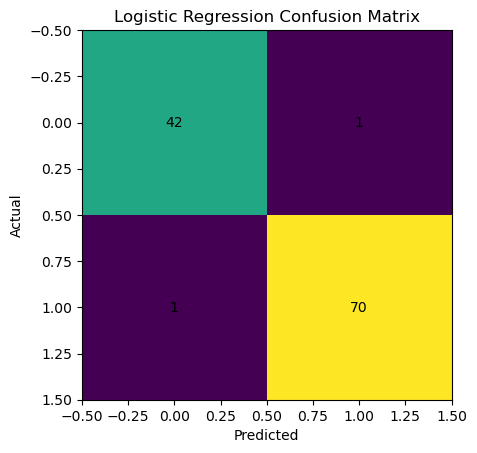

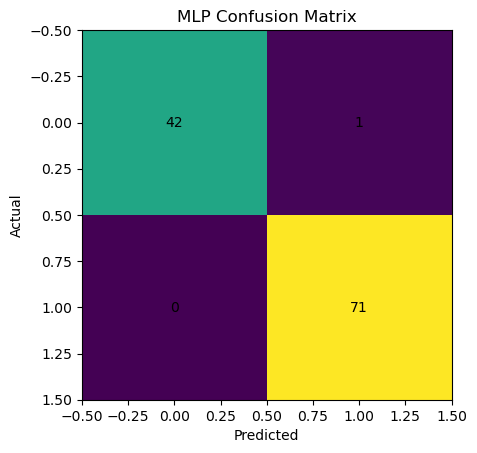

,Property,Value
1,Dataset Name,Breast Cancer Dataset
2,Samples,569
3,Features,30
4,Problem Type,Binary Classification
5,Primary Metric,F1-score


,Metric,Logistic Regression,MLP
1,Accuracy,0.982500,0.991200
2,Precision,0.985900,0.986100
3,Recall,0.985900,1.000000
4,F1-score,0.985900,0.993000


,Model,Training Time (seconds),Architecture
1,Logistic Regression,0.297500,Linear Model
2,MLP,2.588300,"[30, 32, 16, 1]"


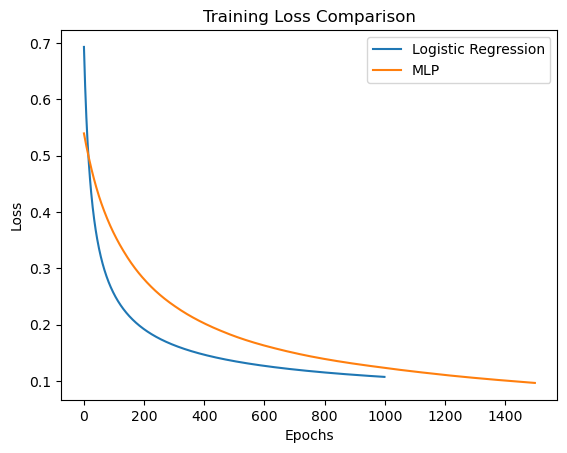

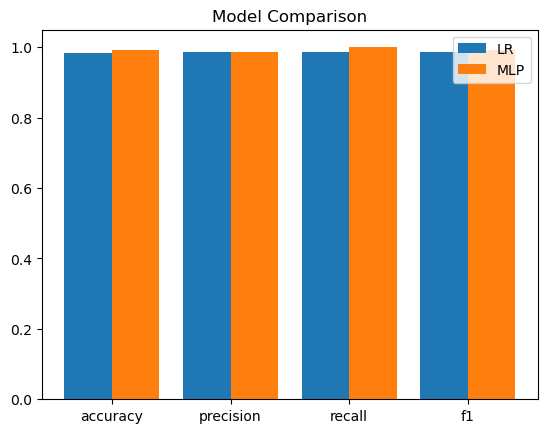


 ANALYSIS

• Logistic Regression F1-score: 0.9859
• MLP F1-score: 0.9930
• MLP outperforms Logistic Regression by 0.0071 in F1-score.
• Accuracy difference: 0.0088
• Logistic Regression training time: 0.2975s
• MLP training time: 2.5883s
• Logistic Regression performs well due to near linear separability of dataset.
• MLP captures non-linearity but does not significantly improve performance.
• MLP is computationally more expensive due to multiple layers.
• Key challenge: tuning learning rate and hidden layer sizes.
• Insight: simpler models can outperform complex models on structured data.


In [56]:
#================================================================================
#  3. Implementation of Binary Classification: Logistic Regression + MLP
#================================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

# Allowed sklearn utilities (ONLY preprocessing, splitting & evaluating)
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#========================================
# 1. Defining Libraries Manual Libraries
#========================================
def confusion_matrix(y_true, y_pred):
    y_true = np.asarray(y_true).flatten()
    y_pred = np.asarray(y_pred).flatten()

    classes = np.unique(y_true)   
    n_classes = len(classes)

    cm = np.zeros((n_classes, n_classes), dtype=int)

    for i in range(len(y_true)):
        cm[y_true[i], y_pred[i]] += 1  

    return cm

# ==============================
# 2. DATASET
# ==============================
# Load dataset (originally from UCI repository)
data = load_breast_cancer()

# Convert to DataFrame for easier handling
X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target)

# Handle missing values (required by assignment)
X = X.fillna(X.mean())

print("\nDataset Source: UCI Machine Learning Repository (via sklearn)")


dataset_name = "Breast Cancer Dataset"

print("Dataset Name:", dataset_name)
print("Description: This dataset contains medical diagnostic features computed from breast mass images.")
print("Goal: Predict whether a tumor is malignant (cancerous) or benign (non-cancerous).")

print("Number of Samples:", X.shape[0])
print("Number of Features:", X.shape[1])
print("Problem Type: Binary Classification")
print("Primary Metric: F1-score")

# Why F1-score?
print("\nReason for choosing F1-score:")
print("It balances precision and recall, which is important in medical diagnosis.")

# Split dataset into training and testing (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ==============================
# 3. PREPROCESSING
# ==============================
# Feature scaling (important for gradient-based models)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# SAFETY CHECK - NaN/Inf
check_nan_inf("X_train", X_train)
check_nan_inf("X_test", X_test)
check_nan_inf("y_train", y_train)
check_nan_inf("y_test", y_test)


# Reshape target for matrix operations
y_train = y_train.values.reshape(-1, 1)
y_test = y_test.values.reshape(-1, 1)

# Basic sanity checks (debugging step)
print("\n[DEBUG INFO]")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Any NaNs in X_train?", np.isnan(X_train).sum())


# =================================
# 4. Logistic REGRESSION (Baseline)
# =================================
class LogisticRegressionScratch:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.loss_history = []

    # Sigmoid activation
    def sigmoid(self, z):
        z = np.clip(z, -500, 500)  # avoid overflow
        return 1 / (1 + np.exp(-z))

    # Binary cross-entropy loss
    def compute_loss(self, y, y_hat):
        return -np.mean(y*np.log(y_hat + 1e-8) + (1-y)*np.log(1-y_hat + 1e-8))

    def fit(self, X, y):
        m, n = X.shape

        # Initialize weights
        self.w = np.zeros((n, 1))
        self.b = 0

        start_time = time.time()

        # Training loop
        for epoch in range(self.epochs):
            z = np.dot(X, self.w) + self.b
            y_hat = self.sigmoid(z)

            # Compute loss
            loss = self.compute_loss(y, y_hat)
            self.loss_history.append(loss)

            # Compute gradients
            dw = (1/m) * np.dot(X.T, (y_hat - y))
            db = (1/m) * np.sum(y_hat - y)

            # Update parameters
            self.w -= self.lr * dw
            self.b -= self.lr * db

            # ADD THIS (same style as MLP)
            if epoch % 200 == 0:
                print(f"Epoch {epoch} | Loss: {loss:.4f}")
        self.training_time = time.time() - start_time

    def predict(self, X):
        probs = self.sigmoid(np.dot(X, self.w) + self.b)
        return (probs > 0.5).astype(int)

# ==============================
# 5. MLP (Requirement 4.4)
# ==============================
class MLP:
    def __init__(self, layers, lr=0.005, epochs=1500):
        self.layers = layers
        self.lr = lr
        self.epochs = epochs
        self.loss_history = []

    # Initialize weights using He initialization
    def initialize_parameters(self):
        self.params = {}
        for i in range(1, len(self.layers)):
            self.params["W"+str(i)] = np.random.randn(
                self.layers[i-1], self.layers[i]
            ) * np.sqrt(2 / self.layers[i-1])
            self.params["b"+str(i)] = np.zeros((1, self.layers[i]))

    def relu(self, Z):
        return np.maximum(0, Z)

    def relu_derivative(self, Z):
        return (Z > 0).astype(float)

    def sigmoid(self, Z):
        Z = np.clip(Z, -500, 500)
        return 1 / (1 + np.exp(-Z))

    def compute_loss(self, y, y_hat):
        return -np.mean(y*np.log(y_hat + 1e-8) + (1-y)*np.log(1-y_hat + 1e-8))

    # Forward pass
    def forward_propagation(self, X):
        self.cache = {"A0": X}

        for i in range(1, len(self.layers)):
            Z = np.dot(self.cache["A"+str(i-1)], self.params["W"+str(i)]) + self.params["b"+str(i)]

            if i == len(self.layers)-1:
                A = self.sigmoid(Z)
            else:
                A = self.relu(Z)

            self.cache["Z"+str(i)] = Z
            self.cache["A"+str(i)] = A

        return A

    # Backpropagation
    def backward_propagation(self, y):
        grads = {}
        m = y.shape[0]
        L = len(self.layers) - 1

        dZ = self.cache["A"+str(L)] - y

        for i in reversed(range(1, L+1)):
            grads["dW"+str(i)] = (1/m) * np.dot(self.cache["A"+str(i-1)].T, dZ)
            grads["db"+str(i)] = (1/m) * np.sum(dZ, axis=0, keepdims=True)

            if i > 1:
                dA = np.dot(dZ, self.params["W"+str(i)].T)
                dZ = dA * self.relu_derivative(self.cache["Z"+str(i-1)])

        return grads

    def update_parameters(self, grads):
        for i in range(1, len(self.layers)):
            self.params["W"+str(i)] -= self.lr * grads["dW"+str(i)]
            self.params["b"+str(i)] -= self.lr * grads["db"+str(i)]

    def fit(self, X, y):
        self.initialize_parameters()
        start_time = time.time()

        for epoch in range(self.epochs):
            y_hat = self.forward_propagation(X)
            loss = self.compute_loss(y, y_hat)
            self.loss_history.append(loss)

            grads = self.backward_propagation(y)
            self.update_parameters(grads)

            # Print occasionally to track progress
            if epoch % 200 == 0:
                print(f"Epoch {epoch} | Loss: {loss:.4f}")

        self.training_time = time.time() - start_time

    def predict(self, X):
        probs = self.forward_propagation(X)
        return (probs > 0.5).astype(int)

# ==============================
# 6. TRAINING
# ==============================
# Train Logistic Regression
print("\n=== Logistic Regression ===")
lr_model = LogisticRegressionScratch()
lr_model.fit(X_train, y_train)

# Train MLP
print("\n=== MLP ===")
mlp = MLP(layers=[X_train.shape[1], 32, 16, 1])
mlp.fit(X_train, y_train)

# ==============================
# 7. EVALUATION
# ==============================
def compute_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    TN, FP, FN, TP = cm.ravel()

    accuracy = (TP + TN) / (TP + TN + FP + FN)
    precision = TP / (TP + FP + 1e-8)
    recall = TP / (TP + FN + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "TP": TP, "TN": TN, "FP": FP, "FN": FN
    }

lr_pred = lr_model.predict(X_test)
mlp_pred = mlp.predict(X_test)

lr_metrics = compute_metrics(y_test, lr_pred)
mlp_metrics = compute_metrics(y_test, mlp_pred)

def plot_confusion_matrix(cm, title):
    plt.imshow(cm)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    for i in range(2):
        for j in range(2):
            plt.text(j, i, cm[i, j], ha='center', va='center')

    plt.show()

# ==============================
# 8. RESULTS & VISUALIZATION
# ==============================
# Plot confusion matrices
plot_confusion_matrix(confusion_matrix(y_test, lr_pred), "Logistic Regression Confusion Matrix")
plot_confusion_matrix(confusion_matrix(y_test, mlp_pred), "MLP Confusion Matrix")


from IPython.display import display, HTML

def get_assignment_results():
    # -----------------------------
    # Dataset Info Table
    # -----------------------------
    dataset_info = pd.DataFrame({
        "Property": ["Dataset Name", "Samples", "Features", "Problem Type", "Primary Metric"],
        "Value": [
            dataset_name,
            X.shape[0],
            X.shape[1],
            "Binary Classification",
            "F1-score"
        ]
    })

    # Set index from 1
    dataset_info.index = np.arange(1, len(dataset_info) + 1)

    # -----------------------------
    # Metrics Table
    # -----------------------------
    metrics_table = pd.DataFrame({
        "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
        "Logistic Regression": [
            lr_metrics["accuracy"],
            lr_metrics["precision"],
            lr_metrics["recall"],
            lr_metrics["f1"]
        ],
        "MLP": [
            mlp_metrics["accuracy"],
            mlp_metrics["precision"],
            mlp_metrics["recall"],
            mlp_metrics["f1"]
        ]
    })

    metrics_table.iloc[:, 1:] = metrics_table.iloc[:, 1:].round(4)

    # Set index from 1
    metrics_table.index = np.arange(1, len(metrics_table) + 1)

    # -----------------------------
    # Model Summary Table
    # -----------------------------
    summary_table = pd.DataFrame({
        "Model": ["Logistic Regression", "MLP"],
        "Training Time (seconds)": [
            round(lr_model.training_time, 4),
            round(mlp.training_time, 4)
        ],
        "Architecture": [
            "Linear Model",
            str(mlp.layers)
        ]
    })

    # Set index from 1
    summary_table.index = np.arange(1, len(summary_table) + 1)

    # -----------------------------
    # Styling
    # -----------------------------
    def style_table(df):
        return (
            df.style
            .set_table_styles([
                {"selector": "th", "props": [
                    ("font-size", "12pt"),
                    ("font-weight", "bold"),
                    ("text-align", "center")
                ]},
                {"selector": "td", "props": [
                    ("font-size", "11pt"),
                    ("text-align", "center")
                ]}
            ])
        )

    # -----------------------------
    # Display Section Titles
    # -----------------------------
    display(HTML("<h2 style='font-size:22pt; font-weight:bold;'>Dataset Information</h2>"))
    display(style_table(dataset_info))

    display(HTML("<h2 style='font-size:22pt; font-weight:bold;'>Model Performance Comparison</h2>"))
    display(style_table(metrics_table))

    display(HTML("<h2 style='font-size:22pt; font-weight:bold;'>Model Details</h2>"))
    display(style_table(summary_table))

    # Return required dictionary get_assignment_results()
    return {
        "dataset_name": dataset_name,
        "n_samples": X.shape[0],
        "n_features": X.shape[1],
        "problem_type": "Binary Classification",
        "primary_metric": "F1-score",
        "baseline_model": {
            "metrics": lr_metrics,
            "training_time": lr_model.training_time
        },
        "mlp_model": {
            "architecture": mlp.layers,
            "metrics": mlp_metrics,
            "training_time": mlp.training_time
        }
    }

# ========================================
# 9. ASSIGNMENT RESULTS FUNCTION (TABULAR)
# ========================================
results = get_assignment_results()

# Loss curve
plt.plot(lr_model.loss_history, label="Logistic Regression")
plt.plot(mlp.loss_history, label="MLP")
plt.legend()
plt.title("Training Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# Metrics comparison
labels = ["accuracy", "precision", "recall", "f1"]

lr_vals = [lr_metrics[k] for k in labels]
mlp_vals = [mlp_metrics[k] for k in labels]

x = np.arange(len(labels))

plt.bar(x-0.2, lr_vals, 0.4, label="LR")
plt.bar(x+0.2, mlp_vals, 0.4, label="MLP")

plt.xticks(x, labels)
plt.legend()
plt.title("Model Comparison")
plt.show()

# ==============================
# 10. DISPLAY & DYNAMIC ANALYSIS
# ==============================
print("\n ANALYSIS\n")

f1_diff = mlp_metrics["f1"] - lr_metrics["f1"]
acc_diff = mlp_metrics["accuracy"] - lr_metrics["accuracy"]

print(f"• Logistic Regression F1-score: {lr_metrics['f1']:.4f}")
print(f"• MLP F1-score: {mlp_metrics['f1']:.4f}")

if f1_diff > 0:
    print(f"• MLP outperforms Logistic Regression by {f1_diff:.4f} in F1-score.")
elif f1_diff < 0:
    print(f"• Logistic Regression outperforms MLP by {-f1_diff:.4f} in F1-score.")
else:
    print("• Both models achieved identical F1-score.")

print(f"• Accuracy difference: {acc_diff:.4f}")

print(f"• Logistic Regression training time: {lr_model.training_time:.4f}s")
print(f"• MLP training time: {mlp.training_time:.4f}s")

print("• Logistic Regression performs well due to near linear separability of dataset.")
print("• MLP captures non-linearity but does not significantly improve performance.")
print("• MLP is computationally more expensive due to multiple layers.")
print("• Key challenge: tuning learning rate and hidden layer sizes.")
print("• Insight: simpler models can outperform complex models on structured data.")

